# Comparing VxE Effect

In [1]:
#First import the various libraries needed
import sys
sys.path.append('/storage/home/hcoda1/9/dmathews33/Spin-tracking/scripts')
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def bootstrapResults(dset, numBootstrap):
    times = []
    means = []
    stds = []
    for i in range(numBootstrap):
        print(i)
        time, mean, std = analyzeDataset(dset, randomSample=True)
        times.append(time)
        means.append(mean)
        stds.append(std)
    times = times[0]
    means = np.array(means)
    stds = np.array(stds)
    return times, means, stds

def analyzeDataset(inpDset, randomSample = False, plot=False):
    errorStates = inpDset[1]['errorState'][-1,:]
    validParticles = np.argwhere(errorStates==0)[:,0]
    times = inpDset[1]['t'][:,0]
    sz = inpDset[1]['s'][:,validParticles,2]
    sy = inpDset[1]['s'][:,validParticles,1]    
    phis = np.arctan2(sz, sy)
    validPhis = np.argwhere(np.logical_not(np.isnan(phis[-1,:])))[:,0]
    phis = phis[:,validPhis]
    for i in range(len(times)):
        if randomSample:
            phis[i,:] = nedmSim.shiftDatapoints(np.random.choice(phis[i,:], size=phis[i,:].shape))
        else:
            phis[i,:] = nedmSim.shiftDatapoints(phis[i,:])
        if plot:
            plt.hist(phis[i,:], bins = 1000)
            plt.title(times[i])
            plt.yscale('log')
            plt.show()
    means = np.nanmean(phis, axis=1)
    means[means > np.pi] -= np.pi*2.0
    means[means < -np.pi] += np.pi*2.0
    stds = np.nanstd(phis, axis=1)
    return times, means, stds, phis.shape[0]

## Initial Lower Number of Particles

In [23]:
#load in the no electric field dataset

tf = 2000.0
tout = 20
numParticles = 65536

parameters = {}
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='0' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='false' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['E'] = '75.0e5, 0, 0' #electric field
parameters['numParticles'] = str(numParticles) #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']=str(tf) #stop time of the simulation
parameters['ioutInt']=str(tout) #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-12' #relative precision desired for spin integration
parameters['atol'] = '1.0e-12' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['seed'] = '0' #random number seed for the first particle
parameters['integratorType'] = '2' #the spin integration method

def runTests(parameters, velocities):
    results = []
    for vel in velocities:
        print('\t', vel)
        parameters['V']=str(vel) #set the velocity if using distribution = 'C'
        filename = 'neutronTest.txt'
        nedmSim.writeParameterFile(filename, parameters)
        outputFile = '/storage/home/hcoda1/9/dmathews33/scratch/precisionTest64bit.out'
        !~/Spin-tracking/bit64main {filename} {outputFile}
        results.append(nedmSim.readInOutputFile(outputFile, pad=3))

    finalResults = []
    for res in results:
        finalResults.append(analyzeDataset(res))
    w = results[0][0]['gamma']*np.sqrt(np.sum(np.square(results[0][0]['B0'])))*np.sign(results[0][0]['B0'][0]) #calculate the frequency
    times = results[0][1]['t'][:,0]
    calcZ = np.cos(w*times)
    calcY = np.sin(w*times)
    calcPhase = np.arctan2(calcZ, calcY)
    shifts = []
    for res in finalResults:
        shift = res[1]-calcPhase
        shift[shift > np.pi] -= 2.0*np.pi
        shift[shift < -np.pi] += 2.0*np.pi
        shifts.append(shift)
    shifts = np.array(shifts)
    out = {}
    out['times'] = times
    out['shifts'] = shifts/times/(2.0*np.pi)*1e9
    errs = []
    for res in finalResults:
        errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)
    errs = np.array(errs)
    out['errors'] = errs
    rawVals = []
    for res in finalResults:
        rawVals.append(res[1])
    rawVals = np.array(rawVals)
    out['rawVals'] = rawVals
    out['w'] = w
    out['calcPhase'] = calcPhase
    params = []
    for res in results:
        params.append(res[0])
    out['parameters'] = params
    return out

In [24]:
velocities = [5]
parameters['gravity'] = 'false'
parameters['diffuse'] = '0'
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
normalField = runTests(parameters, velocities)
parameters['B0'] = '-3.0e-6, 0, 0' #magnetic field
backwards = runTests(parameters, velocities)
#resultsNoGravitySpecular = runTests(parameters, velocities)


	 5
648
iter 0, duration 20, 295
iter 1, duration 40, 266
iter 2, duration 60, 268
iter 3, duration 80, 269
iter 4, duration 100, 268
iter 5, duration 120, 270
iter 6, duration 140, 265
iter 7, duration 160, 268
iter 8, duration 180, 267
iter 9, duration 200, 266
iter 10, duration 220, 265
iter 11, duration 240, 265
iter 12, duration 260, 267
iter 13, duration 280, 268
iter 14, duration 300, 267
iter 15, duration 320, 268
iter 16, duration 340, 268
iter 17, duration 360, 269
iter 18, duration 380, 268
iter 19, duration 400, 266
iter 20, duration 420, 269
iter 21, duration 440, 266
iter 22, duration 460, 269
iter 23, duration 480, 268
iter 24, duration 500, 267
iter 25, duration 520, 267
iter 26, duration 540, 267
iter 27, duration 560, 268
iter 28, duration 580, 267
iter 29, duration 600, 267
iter 30, duration 620, 267
iter 31, duration 640, 267
iter 32, duration 660, 267
iter 33, duration 680, 270
iter 34, duration 700, 267
iter 35, duration 720, 269
iter 36, duration 740, 270
iter 37

<ipython-input-23-52262b9edad3>:61: RuntimeWarning: divide by zero encountered in true_divide
  out['shifts'] = shifts/times/(2.0*np.pi)*1e9
<ipython-input-23-52262b9edad3>:64: RuntimeWarning: divide by zero encountered in true_divide
  errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)


iter 0, duration 20, 276
iter 1, duration 40, 268
iter 2, duration 60, 268
iter 3, duration 80, 270
iter 4, duration 100, 269
iter 5, duration 120, 269
iter 6, duration 140, 268
iter 7, duration 160, 268
iter 8, duration 180, 268
iter 9, duration 200, 268
iter 10, duration 220, 268
iter 11, duration 240, 268
iter 12, duration 260, 269
iter 13, duration 280, 269
iter 14, duration 300, 271
iter 15, duration 320, 268
iter 16, duration 340, 269
iter 17, duration 360, 270
iter 18, duration 380, 270
iter 19, duration 400, 268
iter 20, duration 420, 271
iter 21, duration 440, 270
iter 22, duration 460, 269
iter 23, duration 480, 271
iter 24, duration 500, 270
iter 25, duration 520, 269
iter 26, duration 540, 270
iter 27, duration 560, 269
iter 28, duration 580, 270
iter 29, duration 600, 271
iter 30, duration 620, 270
iter 31, duration 640, 269
iter 32, duration 660, 268
iter 33, duration 680, 271
iter 34, duration 700, 269
iter 35, duration 720, 268
iter 36, duration 740, 270
iter 37, durati

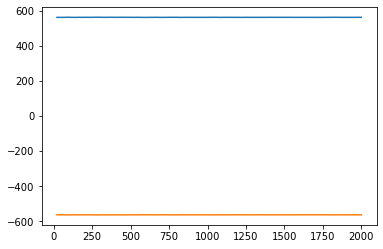

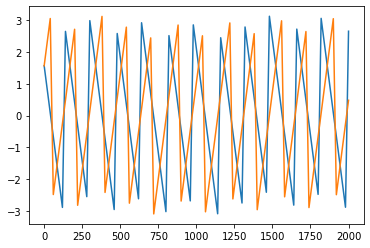

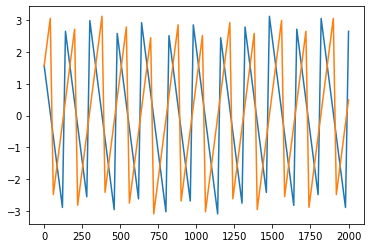

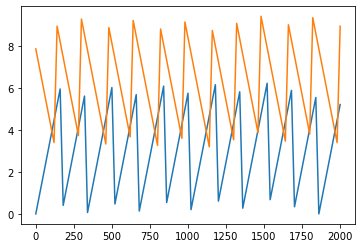

In [18]:
plt.plot(normalField['times'], normalField['shifts'][0,:])
plt.plot(backwards['times'], backwards['shifts'][0,:])
plt.show()

plt.plot(normalField['times'], normalField['rawVals'][0,:])
plt.plot(backwards['times'], backwards['rawVals'][0,:])
plt.show()

plt.plot(normalField['times'], normalField['calcPhase'])
plt.plot(backwards['times'], backwards['calcPhase'])
plt.show()

plt.plot(normalField['times'], np.mod(normalField['w']*normalField['times'], 2.0*np.pi))
fixed = normalField['calcPhase'][:] + 2.0*np.pi
plt.plot(normalField['times'], fixed)
plt.show()

In [196]:
parameters['gravity'] = 'true'
parameters['diffuse'] = '0'
resultsGravitySpecular = runTests(parameters, velocities)

	 1
648
iter 0, duration 20, 14326
iter 1, duration 40, 14205
iter 2, duration 60, 14296
iter 3, duration 80, 14316
iter 4, duration 100, 14397
iter 5, duration 120, 14505
iter 6, duration 140, 14595
iter 7, duration 160, 14595
iter 8, duration 180, 14483
iter 9, duration 200, 14426
iter 10, duration 220, 14373
iter 11, duration 240, 14492
iter 12, duration 260, 14460
iter 13, duration 280, 14415
iter 14, duration 300, 14422
iter 15, duration 320, 14584
iter 16, duration 340, 14444
iter 17, duration 360, 14492
iter 18, duration 380, 14470
iter 19, duration 400, 14426
iter 20, duration 420, 14389
iter 21, duration 440, 14469
iter 22, duration 460, 14489
iter 23, duration 480, 14440
iter 24, duration 500, 14480
iter 25, duration 520, 14464
iter 26, duration 540, 14478
iter 27, duration 560, 14541
iter 28, duration 580, 14579
iter 29, duration 600, 14562
iter 30, duration 620, 14593
iter 31, duration 640, 14570
iter 32, duration 660, 14619
iter 33, duration 680, 14672
iter 34, duration 70

iter 86, duration 1740, 4255
iter 87, duration 1760, 4311
iter 88, duration 1780, 4277
iter 89, duration 1800, 4294
iter 90, duration 1820, 4265
iter 91, duration 1840, 4280
iter 92, duration 1860, 4295
iter 93, duration 1880, 4277
iter 94, duration 1900, 4321
iter 95, duration 1920, 4269
iter 96, duration 1940, 4282
iter 97, duration 1960, 4302
iter 98, duration 1980, 4326
iter 99, duration 2000, 4301
463919
	 4
648
iter 0, duration 20, 3194
iter 1, duration 40, 3363
iter 2, duration 60, 3513
iter 3, duration 80, 3576
iter 4, duration 100, 3584
iter 5, duration 120, 3688
iter 6, duration 140, 3800
iter 7, duration 160, 3823
iter 8, duration 180, 3825
iter 9, duration 200, 3891
iter 10, duration 220, 3851
iter 11, duration 240, 3815
iter 12, duration 260, 3791
iter 13, duration 280, 3708
iter 14, duration 300, 3681
iter 15, duration 320, 3694
iter 16, duration 340, 3701
iter 17, duration 360, 3711
iter 18, duration 380, 3732
iter 19, duration 400, 3770
iter 20, duration 420, 3741
iter 

<ipython-input-194-704875d1e520>:61: RuntimeWarning: divide by zero encountered in true_divide
  out['shifts'] = shifts/times/(2.0*np.pi)*1e9
<ipython-input-194-704875d1e520>:64: RuntimeWarning: divide by zero encountered in true_divide
  errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)


In [197]:
parameters['gravity'] = 'false'
parameters['diffuse'] = '0.01'
resultsNoGravityDiffuse = runTests(parameters, velocities)

	 1
648
iter 0, duration 20, 1329
iter 1, duration 40, 1245
iter 2, duration 60, 1240
iter 3, duration 80, 1233
iter 4, duration 100, 1237
iter 5, duration 120, 1239
iter 6, duration 140, 1238
iter 7, duration 160, 1247
iter 8, duration 180, 1241
iter 9, duration 200, 1238
iter 10, duration 220, 1238
iter 11, duration 240, 1225
iter 12, duration 260, 1239
iter 13, duration 280, 1233
iter 14, duration 300, 1240
iter 15, duration 320, 1239
iter 16, duration 340, 1234
iter 17, duration 360, 1240
iter 18, duration 380, 1237
iter 19, duration 400, 1229
iter 20, duration 420, 1236
iter 21, duration 440, 1238
iter 22, duration 460, 1240
iter 23, duration 480, 1236
iter 24, duration 500, 1241
iter 25, duration 520, 1236
iter 26, duration 540, 1234
iter 27, duration 560, 1234
iter 28, duration 580, 1239
iter 29, duration 600, 1236
iter 30, duration 620, 1249
iter 31, duration 640, 1241
iter 32, duration 660, 1237
iter 33, duration 680, 1238
iter 34, duration 700, 1230
iter 35, duration 720, 122

iter 95, duration 1920, 591
iter 96, duration 1940, 588
iter 97, duration 1960, 624
iter 98, duration 1980, 623
iter 99, duration 2000, 600
61823
	 4
648
iter 0, duration 20, 575
iter 1, duration 40, 548
iter 2, duration 60, 561
iter 3, duration 80, 589
iter 4, duration 100, 583
iter 5, duration 120, 573
iter 6, duration 140, 614
iter 7, duration 160, 545
iter 8, duration 180, 565
iter 9, duration 200, 609
iter 10, duration 220, 581
iter 11, duration 240, 551
iter 12, duration 260, 560
iter 13, duration 280, 589
iter 14, duration 300, 554
iter 15, duration 320, 575
iter 16, duration 340, 564
iter 17, duration 360, 594
iter 18, duration 380, 568
iter 19, duration 400, 578
iter 20, duration 420, 555
iter 21, duration 440, 575
iter 22, duration 460, 581
iter 23, duration 480, 596
iter 24, duration 500, 596
iter 25, duration 520, 581
iter 26, duration 540, 575
iter 27, duration 560, 620
iter 28, duration 580, 589
iter 29, duration 600, 586
iter 30, duration 620, 560
iter 31, duration 640, 

<ipython-input-194-704875d1e520>:61: RuntimeWarning: divide by zero encountered in true_divide
  out['shifts'] = shifts/times/(2.0*np.pi)*1e9
<ipython-input-194-704875d1e520>:64: RuntimeWarning: divide by zero encountered in true_divide
  errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)


In [218]:
parameters['gravity'] = 'true'
parameters['diffuse'] = '0.10'
resultsGravityDiffuse = runTests(parameters, velocities)

	 1
648
iter 0, duration 20, 20912
iter 1, duration 40, 7745
^C


KeyboardInterrupt: 

In [ ]:
for i in range(len(velocities)):
    plt.figure(figsize=(10, 5))
    plt.errorbar(resultsNoGravitySpecular['times'], resultsNoGravitySpecular['shifts'][i,:], 
                 yerr=resultsNoGravitySpecular['errors'][i,:], label='No Gravity, Specular', linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravitySpecular['times'], resultsGravitySpecular['shifts'][i,:], 
    #             yerr=resultsGravitySpecular['errors'][i,:], label='Gravity, Specular')
    
    plt.errorbar(resultsNoGravityDiffuse['times'], resultsNoGravityDiffuse['shifts'][i,:], 
                 yerr=resultsNoGravityDiffuse['errors'][i,:], label='No Gravity, 1% Diffuse', linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravityDiffuse['times'], resultsGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsGravityDiffuse['errors'][i,:], label='Gravity, 1% Diffuse')
    plt.legend(loc='upper left')
    plt.title(str(velocities[i])+' m/s')
    plt.xlabel('Time (s)')
    plt.ylabel('Shift (nHz)')
    #plt.yscale('symlog')
    plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(len(velocities)):
    plt.errorbar(resultsNoGravitySpecular['times'], resultsNoGravitySpecular['shifts'][i,:], 
                 yerr=resultsNoGravitySpecular['errors'][i,:], label=str(velocities[i]), linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravitySpecular['times'], resultsGravitySpecular['shifts'][i,:], 
    #             yerr=resultsGravitySpecular['errors'][i,:], label='Gravity, Specular')
    
    #plt.errorbar(resultsNoGravityDiffuse['times'], resultsNoGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsNoGravityDiffuse['errors'][i,:], label='No Gravity, 1% Diffuse', linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravityDiffuse['times'], resultsGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsGravityDiffuse['errors'][i,:], label='Gravity, 1% Diffuse')
#plt.legend(loc='upper left')
plt.title(str(velocities[i])+' m/s, No Gravity, Specular Collisions')
plt.xlabel('Time (s)')
plt.ylabel('Shift (nHz)')
#plt.yscale('symlog')
plt.show()

plt.figure(figsize=(10, 5))
for i in range(len(velocities)):
    #plt.errorbar(resultsNoGravitySpecular['times'], resultsNoGravitySpecular['shifts'][i,:], 
    #             yerr=resultsNoGravitySpecular['errors'][i,:], label=str(velocities[i]), linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravitySpecular['times'], resultsGravitySpecular['shifts'][i,:], 
    #             yerr=resultsGravitySpecular['errors'][i,:], label='Gravity, Specular')
    
    plt.errorbar(resultsNoGravityDiffuse['times'], resultsNoGravityDiffuse['shifts'][i,:], 
                 yerr=resultsNoGravityDiffuse['errors'][i,:], label=str(velocities[i]), linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravityDiffuse['times'], resultsGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsGravityDiffuse['errors'][i,:], label='Gravity, 1% Diffuse')
plt.legend(loc='upper left')
plt.title(str(velocities[i])+' m/s, No Gravity, 1% Diffuse Collisions')
plt.xlabel('Time (s)')
plt.ylabel('Shift (nHz)')
#plt.yscale('symlog')
plt.show()

plt.figure(figsize=(10, 5))
for i in range(len(velocities)):
    #plt.errorbar(resultsNoGravitySpecular['times'], resultsNoGravitySpecular['shifts'][i,:], 
    #             yerr=resultsNoGravitySpecular['errors'][i,:], label=str(velocities[i]), linestyle='none', capsize=6)
    
    plt.errorbar(resultsGravitySpecular['times'], resultsGravitySpecular['shifts'][i,:], 
                 yerr=resultsGravitySpecular['errors'][i,:], label=str(velocities[i]))
    
    #plt.errorbar(resultsNoGravityDiffuse['times'], resultsNoGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsNoGravityDiffuse['errors'][i,:], label='No Gravity, 1% Diffuse', linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravityDiffuse['times'], resultsGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsGravityDiffuse['errors'][i,:], label='Gravity, 1% Diffuse')
plt.legend(loc='upper left')
plt.title(str(velocities[i])+' m/s initially, Gravity, Specular Collisions')
plt.xlabel('Time (s)')
plt.ylabel('Shift (nHz)')
#plt.yscale('symlog')
plt.show()

plt.figure(figsize=(10, 5))
for i in range(len(velocities)):
    #plt.errorbar(resultsNoGravitySpecular['times'], resultsNoGravitySpecular['shifts'][i,:], 
    #             yerr=resultsNoGravitySpecular['errors'][i,:], label=str(velocities[i]), linestyle='none', capsize=6)
    
    #plt.errorbar(resultsGravitySpecular['times'], resultsGravitySpecular['shifts'][i,:], 
    #             yerr=resultsGravitySpecular['errors'][i,:], label='Gravity, Specular')
    
    #plt.errorbar(resultsNoGravityDiffuse['times'], resultsNoGravityDiffuse['shifts'][i,:], 
    #             yerr=resultsNoGravityDiffuse['errors'][i,:], label='No Gravity, 1% Diffuse', linestyle='none', capsize=6)
    
    plt.errorbar(resultsGravityDiffuse['times'], resultsGravityDiffuse['shifts'][i,:], 
                 yerr=resultsGravityDiffuse['errors'][i,:], label=str(velocities[i]))
plt.legend(loc='upper left')
plt.title(str(velocities[i])+' m/s initially, Gravity, 1% Diffuse Collisions')
plt.xlabel('Time (s)')
plt.ylabel('Shift (nHz)')
#plt.yscale('symlog')
plt.show()

In [ ]:
diffs = np.logspace(-6, -1, num=6)
velocities = [5]
diffusionTestRes = []
for diff in diffs:
    parameters['diffuse'] = str(diff)
    parameters['gravity'] = 'true'
    res = runTests(parameters, velocities)
    diffusionTestRes.append(res)

	 5
648
iter 0, duration 20, 2326
iter 1, duration 40, 2344
iter 2, duration 60, 2459
iter 3, duration 80, 2556
iter 4, duration 100, 2591
iter 5, duration 120, 2693
iter 6, duration 140, 2766
iter 7, duration 160, 2841
iter 8, duration 180, 2887
iter 9, duration 200, 2849
iter 10, duration 220, 2877
iter 11, duration 240, 2920
iter 12, duration 260, 2932
iter 13, duration 280, 2910
iter 14, duration 300, 2905
iter 15, duration 320, 2930
iter 16, duration 340, 2928
iter 17, duration 360, 2895
iter 18, duration 380, 2919
iter 19, duration 400, 2936
iter 20, duration 420, 2928
iter 21, duration 440, 2942
iter 22, duration 460, 2944
iter 23, duration 480, 2996
iter 24, duration 500, 3002
iter 25, duration 520, 3034
iter 26, duration 540, 3038
iter 27, duration 560, 3047
iter 28, duration 580, 3038
iter 29, duration 600, 3084
iter 30, duration 620, 3106
iter 31, duration 640, 3105
iter 32, duration 660, 3122
iter 33, duration 680, 3171
iter 34, duration 700, 3160
iter 35, duration 720, 318

<ipython-input-3-57f3aef84ead>:60: RuntimeWarning: divide by zero encountered in true_divide
  out['shifts'] = shifts/times/(2.0*np.pi)*1e9
<ipython-input-3-57f3aef84ead>:63: RuntimeWarning: divide by zero encountered in true_divide
  errs.append(res[2]/np.sqrt(res[3])/times/(2.0*np.pi)*1e9)


iter 0, duration 20, 2252
iter 1, duration 40, 2378
iter 2, duration 60, 2509
iter 3, duration 80, 2593
iter 4, duration 100, 2675
iter 5, duration 120, 2778
iter 6, duration 140, 2882
iter 7, duration 160, 2948
iter 8, duration 180, 3000
iter 9, duration 200, 3017
iter 10, duration 220, 3048
iter 11, duration 240, 3090
iter 12, duration 260, 3113
iter 13, duration 280, 3141
iter 14, duration 300, 3152
iter 15, duration 320, 3181
iter 16, duration 340, 3206
iter 17, duration 360, 3217
iter 18, duration 380, 3259
iter 19, duration 400, 3261
iter 20, duration 420, 3315
iter 21, duration 440, 3316
iter 22, duration 460, 3349
iter 23, duration 480, 3390
iter 24, duration 500, 3383
iter 25, duration 520, 3403
iter 26, duration 540, 3447
iter 27, duration 560, 3442
iter 28, duration 580, 3488
iter 29, duration 600, 3474
iter 30, duration 620, 3534
iter 31, duration 640, 3488
iter 32, duration 660, 3556
iter 33, duration 680, 3510
iter 34, duration 700, 3556
iter 35, duration 720, 3525
iter 3

iter 88, duration 1780, 3022
iter 89, duration 1800, 3019
iter 90, duration 1820, 3001
iter 91, duration 1840, 3006
iter 92, duration 1860, 3018
iter 93, duration 1880, 2982
iter 94, duration 1900, 2994
iter 95, duration 1920, 2988
iter 96, duration 1940, 3064
iter 97, duration 1960, 2981
iter 98, duration 1980, 3024
iter 99, duration 2000, 3028
296731
0
	 5
648
iter 0, duration 20, 2274
iter 1, duration 40, 2371
iter 2, duration 60, 2460
iter 3, duration 80, 2492
iter 4, duration 100, 2514
iter 5, duration 120, 2557
iter 6, duration 140, 2597
iter 7, duration 160, 2630
iter 8, duration 180, 2636
iter 9, duration 200, 2633
iter 10, duration 220, 2651
iter 11, duration 240, 2675
iter 12, duration 260, 2708
iter 13, duration 280, 2725
iter 14, duration 300, 2725
iter 15, duration 320, 2749
iter 16, duration 340, 2753
iter 17, duration 360, 2771
iter 18, duration 380, 2809
iter 19, duration 400, 2810
iter 20, duration 420, 2815
iter 21, duration 440, 2818
iter 22, duration 460, 2819
iter 

In [ ]:
for i in range(len(diffs)):
    diff = diffs[i]
    res = diffusionTestRes[i]
    
    plt.figure(figsize=(10, 5))
    plt.errorbar(res['times'], res['shifts'][i,:],yerr=resultsNoGravitySpecular['errors'][i,:], label='No Gravity, Specular')

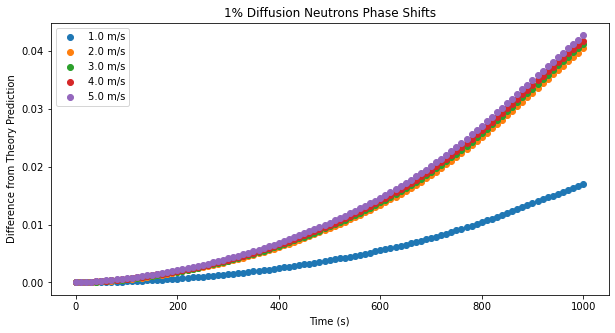

In [10]:
w = results[0][0]['gamma']*np.sqrt(np.sum(np.square(results[0][0]['B0']))) #calculate the frequency
times = results[0][1][0,:]['t']
calcZ = np.cos(w*times)
calcY = np.sin(w*times)
calcPhase = np.arctan2(calcZ, calcY)
shifts = []
for res in finalResults:
    shift = res[1]-calcPhase
    shift[shift > np.pi]-= 2.0*np.pi
    shift[shift < -np.pi] += 2.0*np.pi
    shifts.append(shift)
    
plt.figure(figsize=(10, 5))
for i in range(len(shifts)):
    plt.scatter(times, shifts[i], label=str(results[i][0]['V'])+' m/s')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Difference from Theory Prediction')
plt.title("1% Diffusion Neutrons Phase Shifts")
plt.show()

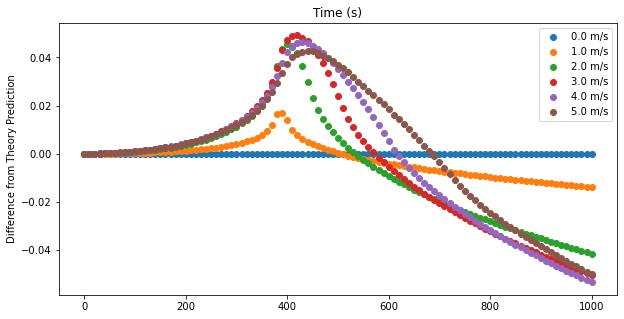

In [108]:
w = results[0][0]['gamma']*np.sqrt(np.sum(np.square(results[0][0]['B0']))) #calculate the frequency
times = results[0][1][0,:]['t']
calcZ = np.cos(w*times)
calcY = np.sin(w*times)
calcPhase = np.arctan2(calcZ, calcY)
shifts = []
for res in finalResults:
    shift = res[1]-calcPhase
    shift[shift > np.pi]-= 2.0*np.pi
    shift[shift < -np.pi] += 2.0*np.pi
    shifts.append(shift)
    
plt.figure(figsize=(10, 5))
for i in range(len(shifts)):
    plt.scatter(times, shifts[i], label=str(results[i][0]['V'])+' m/s')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Difference from Theory Prediction')
plt.title("No Dispersion Neutrons Phase Shifts")
plt.show()

In [65]:
calcPhase

array([ 1.57079633e+00,  2.35656608e+00, -3.14084947e+00, -2.35507971e+00,
       -1.56930995e+00, -7.83540194e-01,  2.22956269e-03,  7.87999320e-01,
        1.57376908e+00,  2.35953883e+00, -3.13787672e+00])

In [66]:
plt.scatter()

(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([1.57079633, 0.78502657, 6.28244212, 5.49667237, 4.71090261,
        3.92513286, 3.1393631 , 2.35359335, 1.56782359, 0.78205383,
        6.27946939]),
 array([1.91402449e-13, 7.62588469e-10, 1.50811049e-09, 2.29352430e-09,
        3.10453109e-09, 4.05997621e-09, 5.29009456e-09, 6.62630530e-09,
        7.75469626e-09, 8.83877138e-09, 1.01075012e-08]))

## 1m/s

In [5]:
#load in the no electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/neutrons/fullField/RK45_1ms/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parameters1ms= []
dataset1ms = []
for f in original:
    temp = readInOutputFile(f)
    parameters1ms.append(temp[0])
    dataset1ms.append(temp[1])
parameters1ms = np.array(parameters1ms)
dataset1ms = np.concatenate(np.array(dataset1ms), axis=0)
numParts1ms = dataset1ms.shape[0]

322


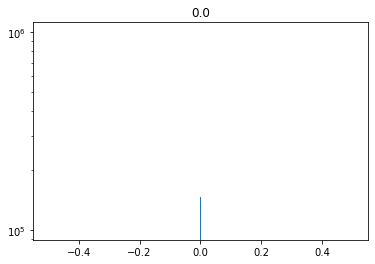

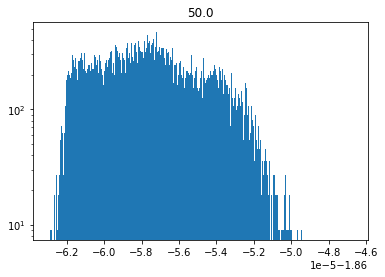

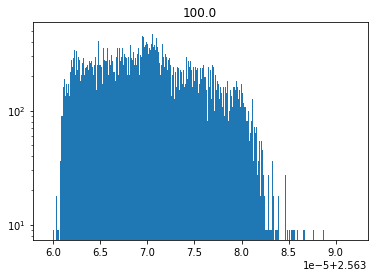

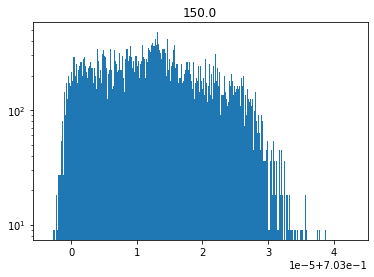

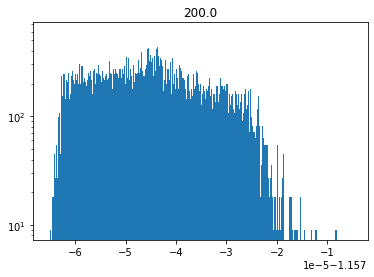

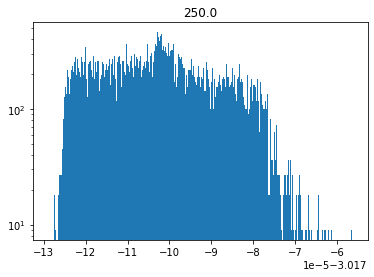

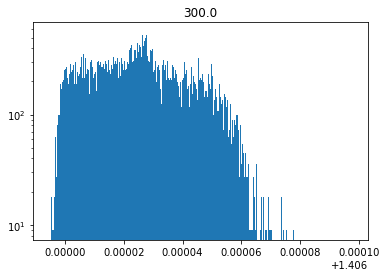

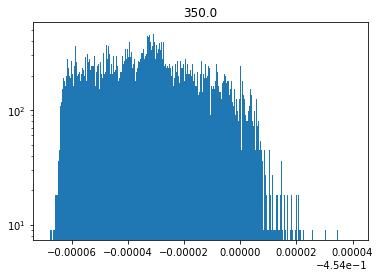

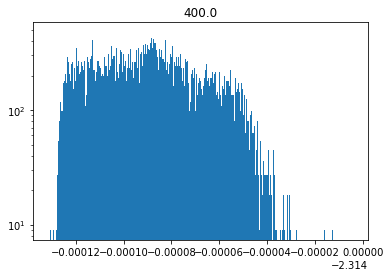

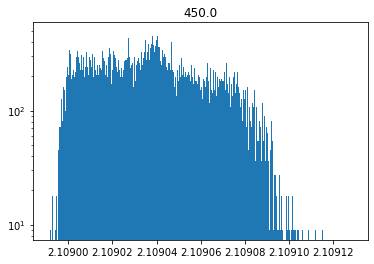

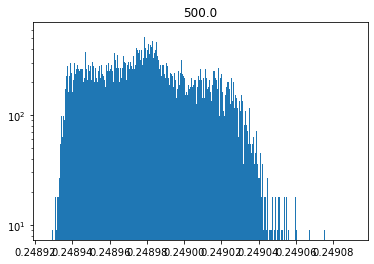

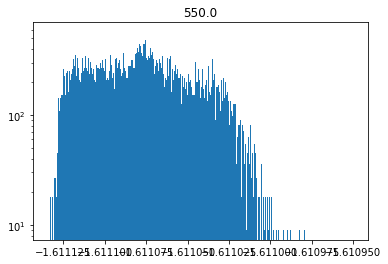

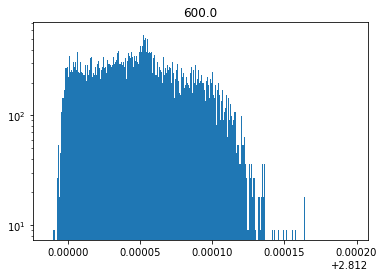

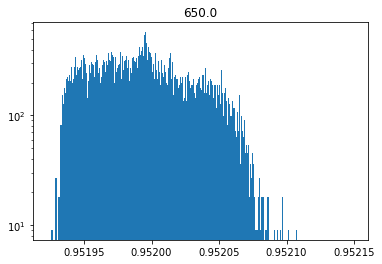

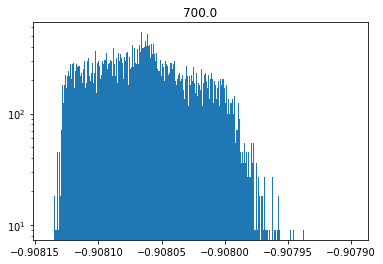

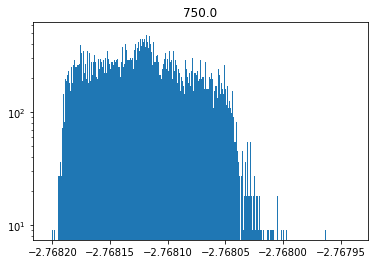

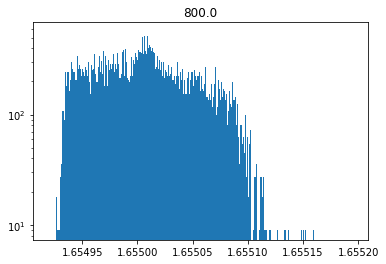

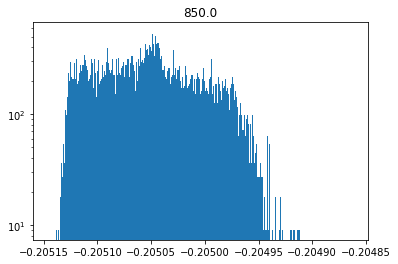

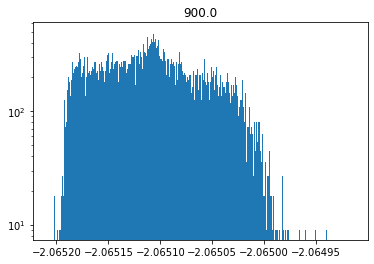

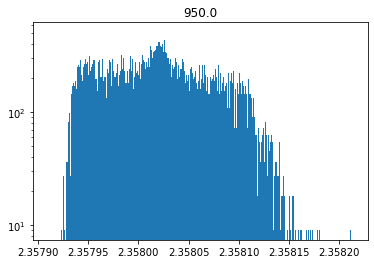

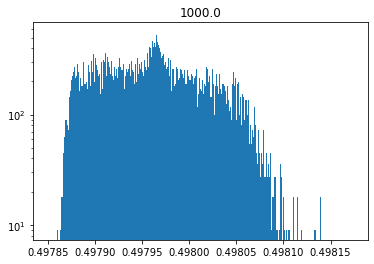

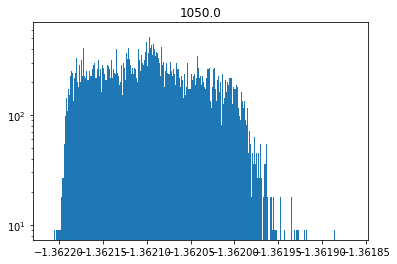

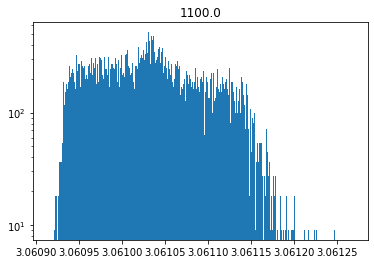

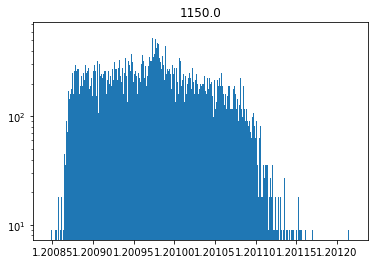

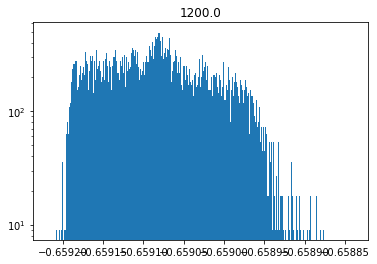

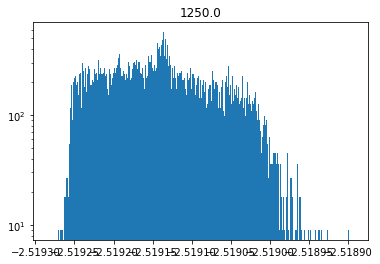

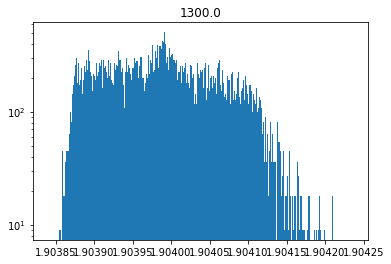

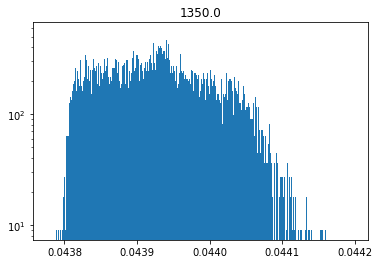

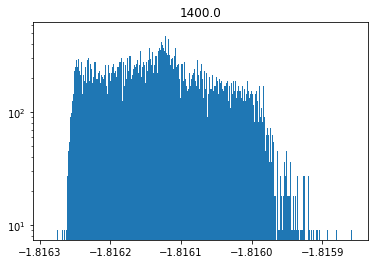

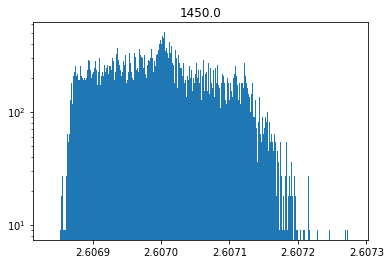

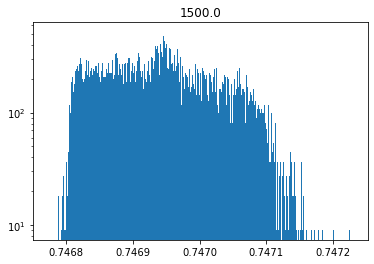

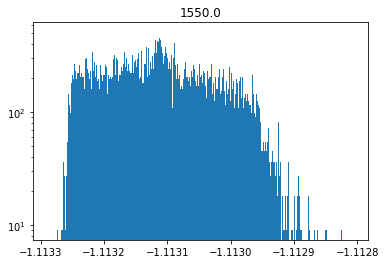

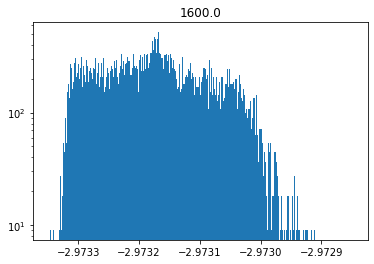

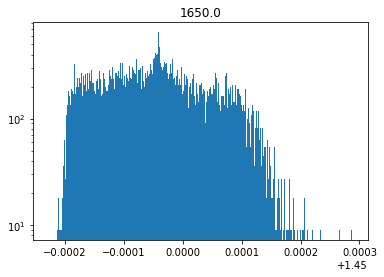

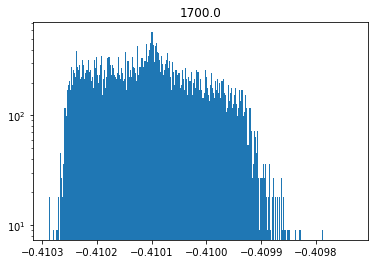

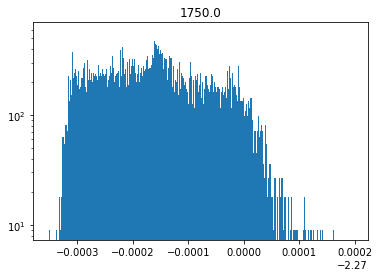

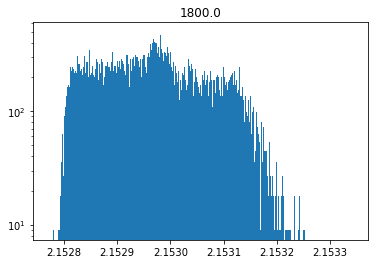

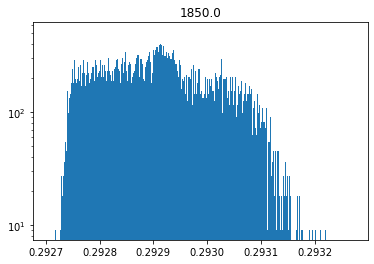

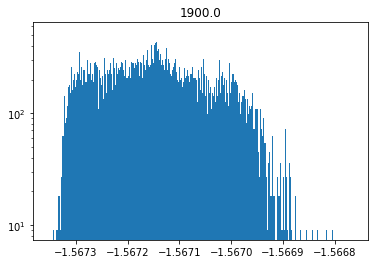

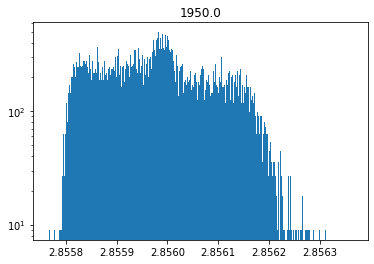

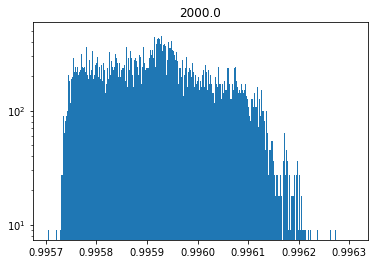

In [6]:
results1ms = analyzeDataset(dataset1ms, plot=True)

## 2 m/s

In [7]:
#load in the no electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/neutrons/fullField/RK45_2ms/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parameters2ms= []
dataset2ms = []
for f in original:
    temp = readInOutputFile(f)
    parameters2ms.append(temp[0])
    dataset2ms.append(temp[1])
parameters2ms = np.array(parameters2ms)
dataset2ms = np.concatenate(np.array(dataset2ms), axis=0)
numParts2ms = dataset2ms.shape[0]

ValueError: max() arg is an empty sequence

In [ ]:
results2ms = analyzeDataset(dataset2ms, plot=True)

## 3 m/s

In [8]:
#load in the no electric field dataset

directory = '/storage/home/hcoda1/9/dmathews33/scratch/neutrons/fullField/RK45_3ms/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parameters3ms= []
dataset3ms = []
for f in original:
    temp = readInOutputFile(f)
    parameters3ms.append(temp[0])
    dataset3ms.append(temp[1])
parameters3ms = np.array(parameters3ms)
dataset3ms = np.concatenate(np.array(dataset3ms), axis=0)
numParts3ms = dataset3ms.shape[0]

1793


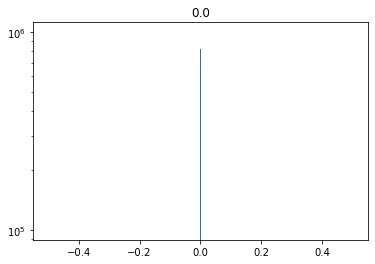

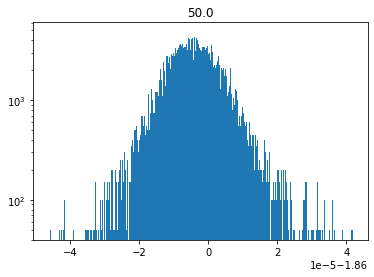

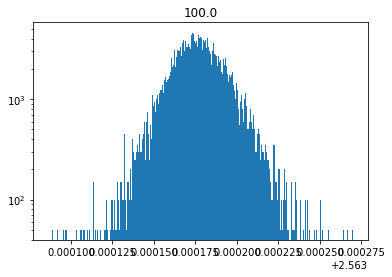

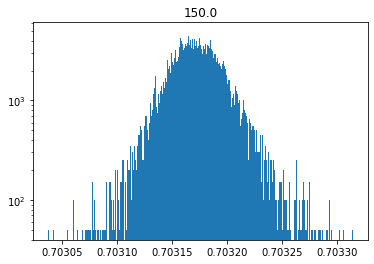

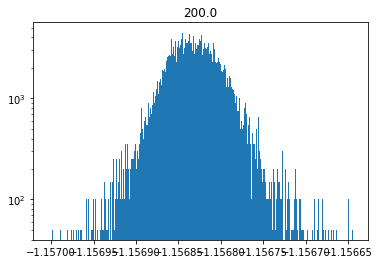

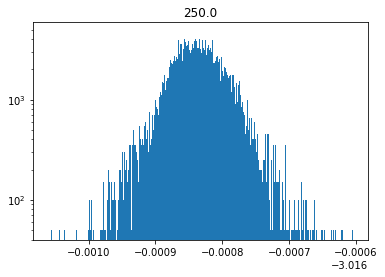

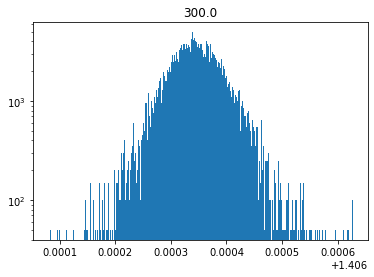

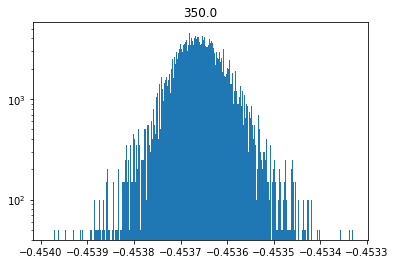

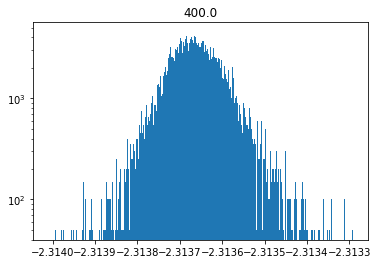

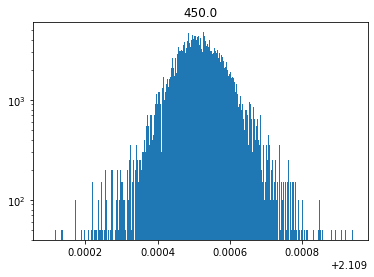

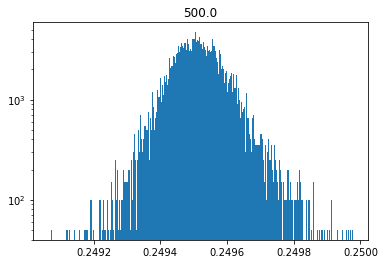

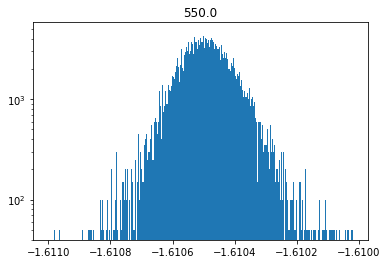

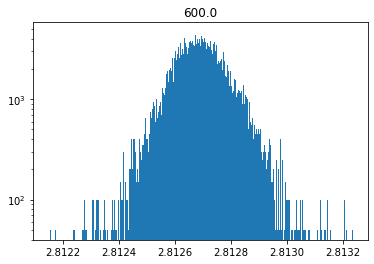

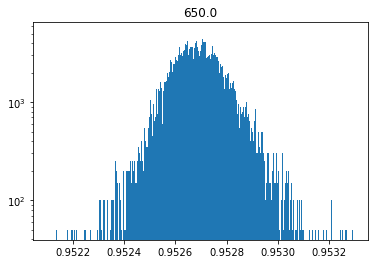

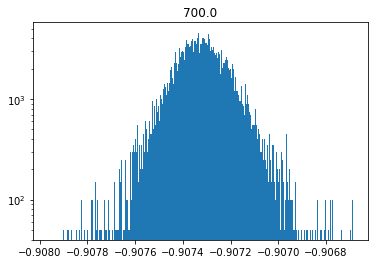

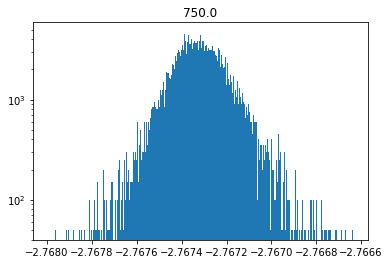

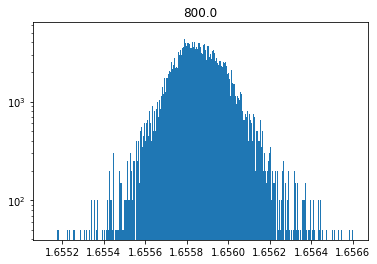

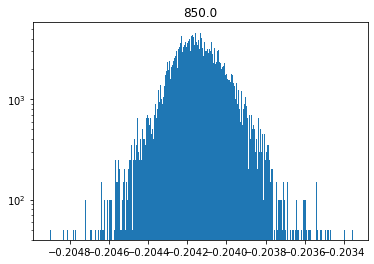

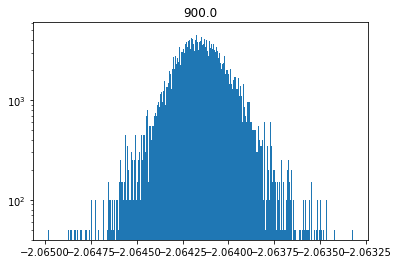

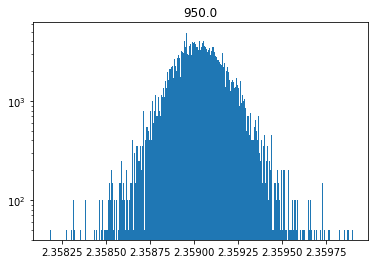

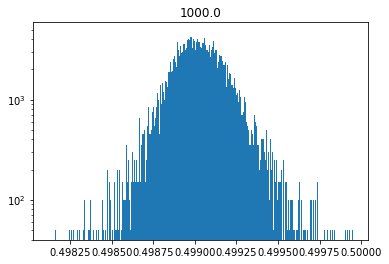

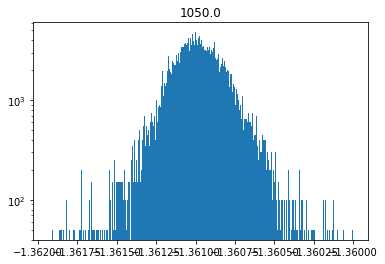

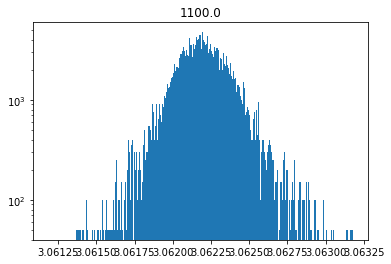

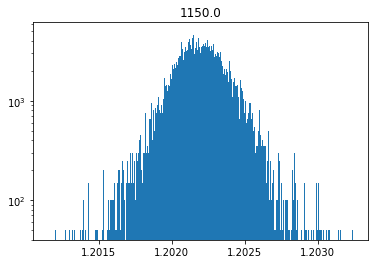

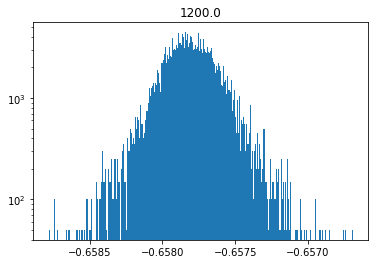

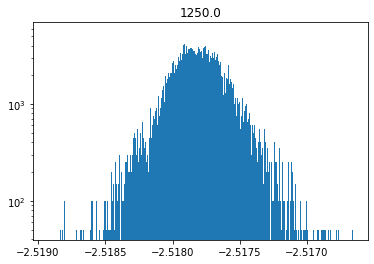

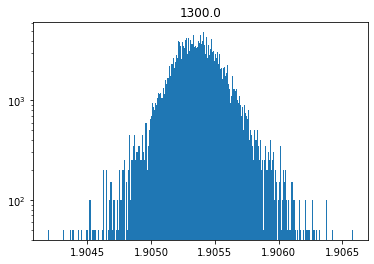

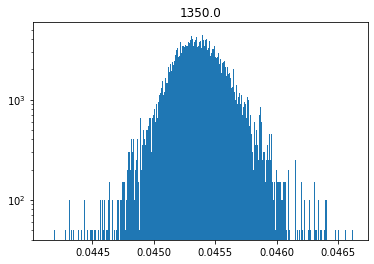

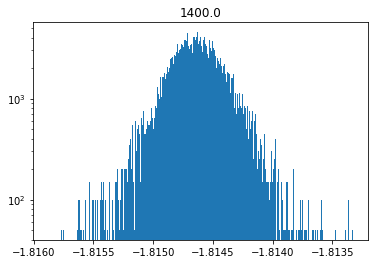

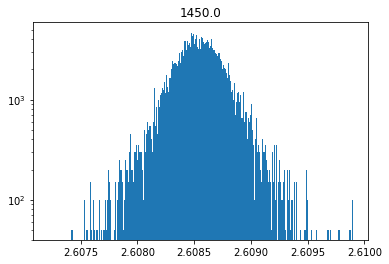

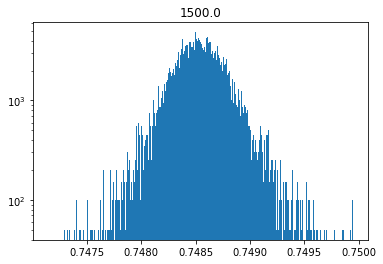

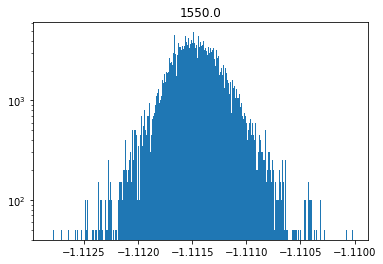

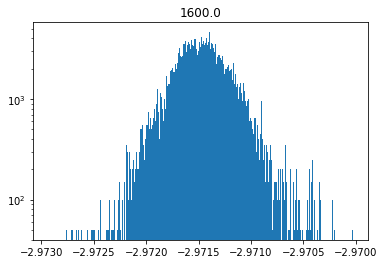

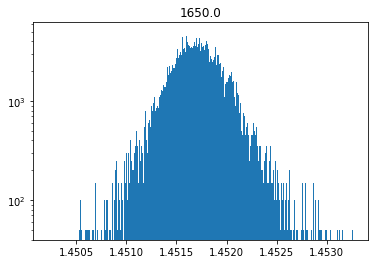

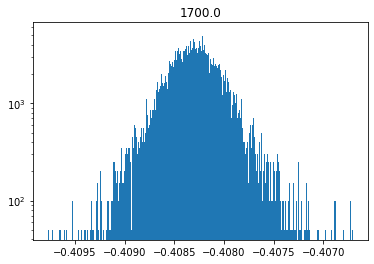

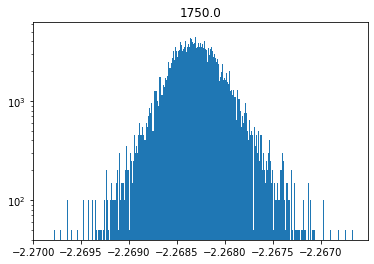

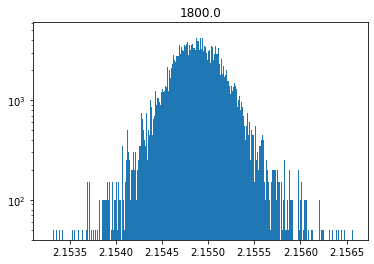

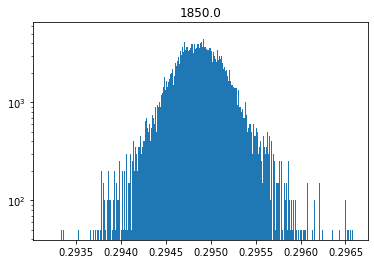

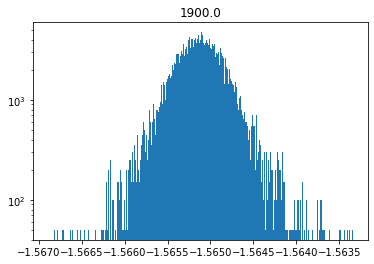

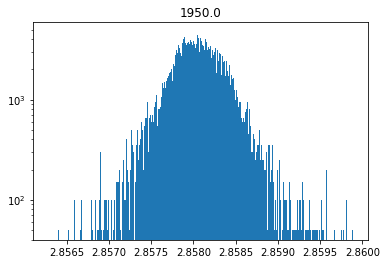

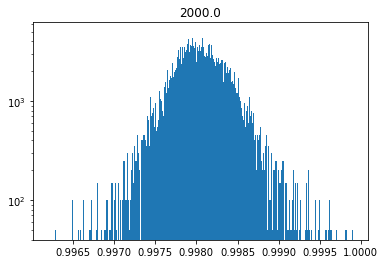

In [9]:
results3ms = analyzeDataset(dataset3ms, plot=True)

## 4 m/s

In [ ]:
#load in the full electric field dataset
directory = '/storage/home/hcoda1/9/dmathews33/scratch/neutrons/fullField/RK45_4ms/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parameters4ms = []
dataset4ms = []
for f in original:
    temp = readInOutputFile(f)
    parameters4ms.append(temp[0])
    dataset3ms.append(temp[1])
parameters4ms = np.array(parameters4ms)
dataset4ms = np.concatenate(np.array(dataset4ms), axis=0)
numParts4ms = dataset4ms.shape[0]

In [ ]:
results4ms = analyzeDataset(dataset4ms, plot=True)

## 5 m/s

In [11]:
#load in the full electric field dataset
directory = '/storage/home/hcoda1/9/dmathews33/scratch/neutrons/fullField/RK45_5ms/'
allFiles = os.listdir(directory)
sizes = []
for f in allFiles:
    sizes.append(os.stat(directory + f).st_size)
sizes = np.array(sizes)
maxSize = max(sizes)

totalSize = 0
original = []
for f in allFiles:
    if os.stat(directory + f).st_size == maxSize:
        totalSize += maxSize
        original.append(directory + f)
print(totalSize//(1024 * 1024))

parameters5ms = []
dataset5ms = []
for f in original:
    temp = readInOutputFile(f)
    parameters5ms.append(temp[0])
    dataset5ms.append(temp[1])
parameters5ms = np.array(parameters5ms)
dataset5ms = np.concatenate(np.array(dataset5ms), axis=0)
numParts5ms = dataset5ms.shape[0]

26583


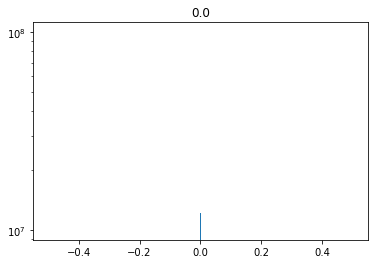

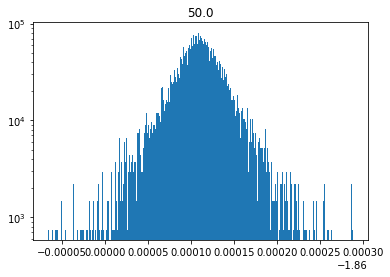

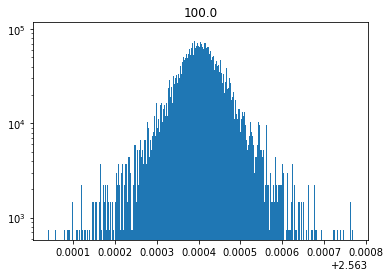

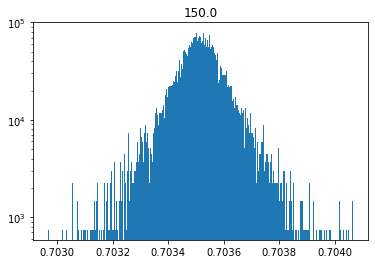

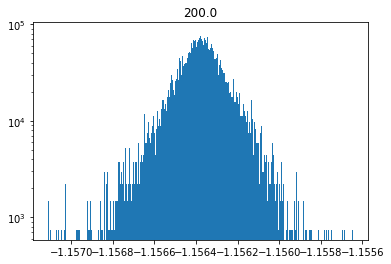

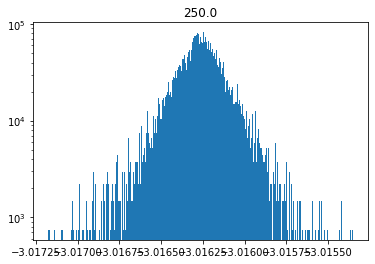

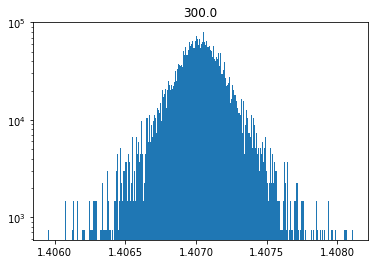

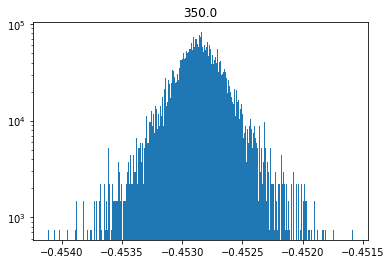

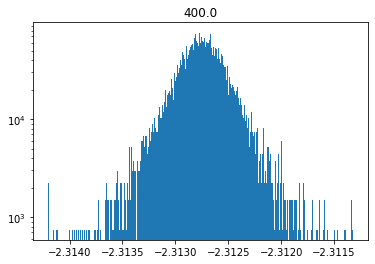

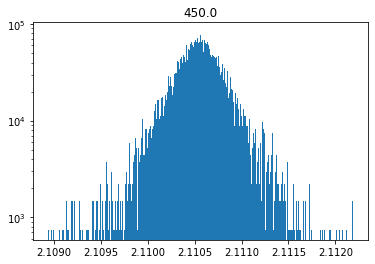

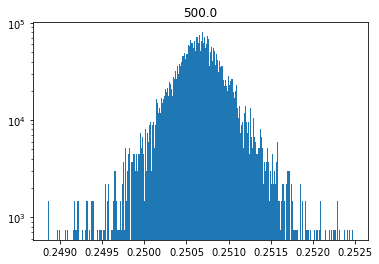

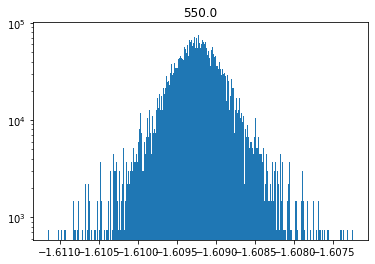

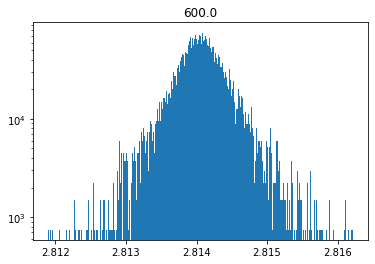

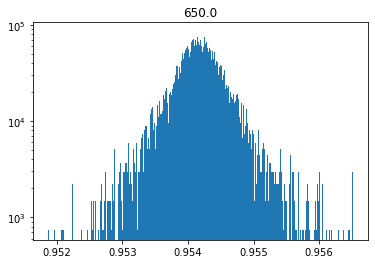

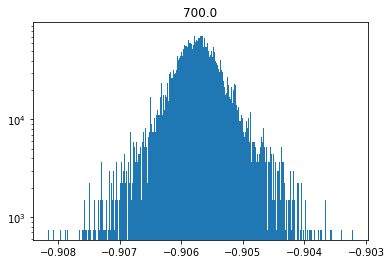

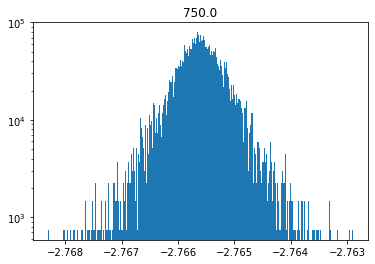

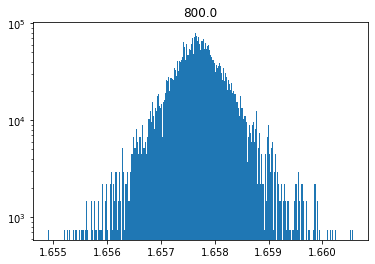

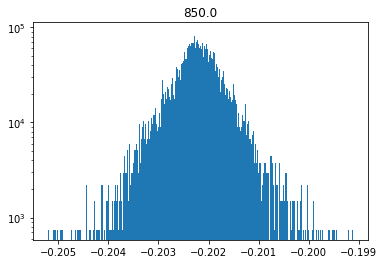

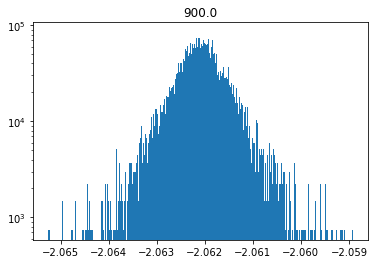

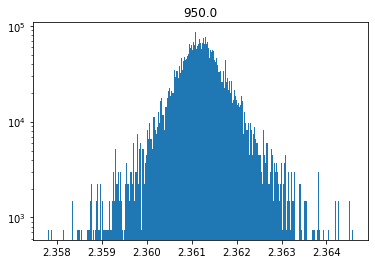

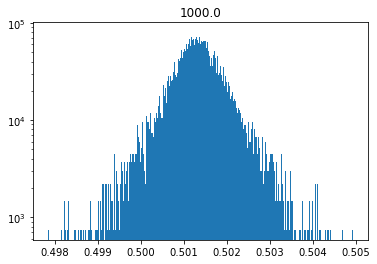

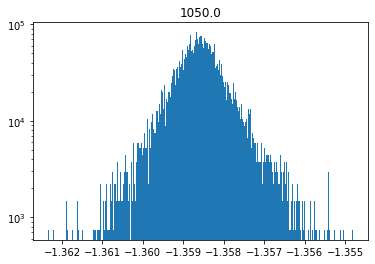

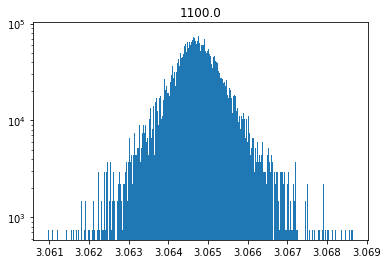

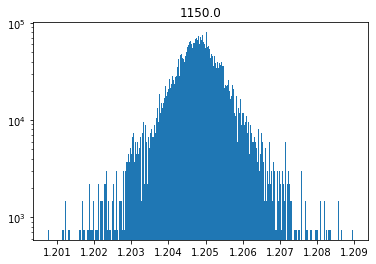

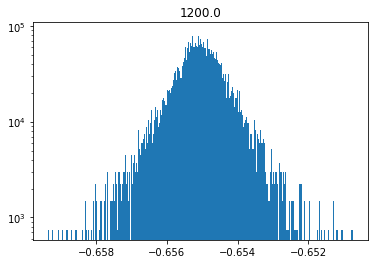

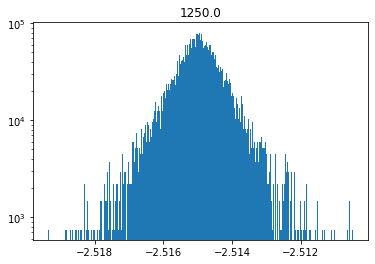

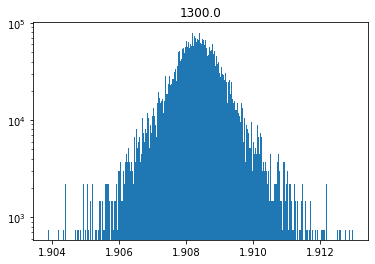

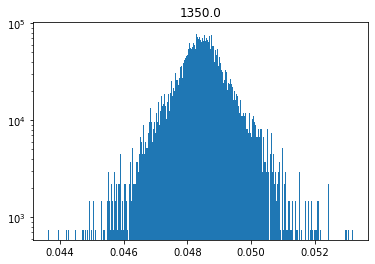

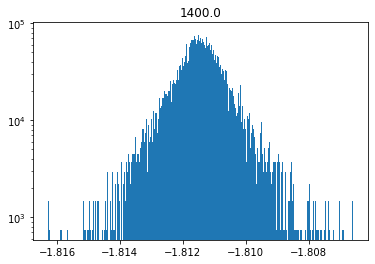

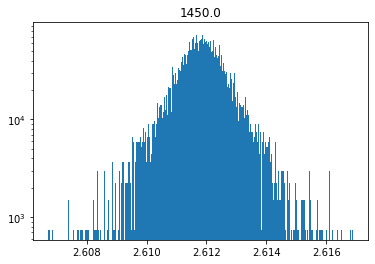

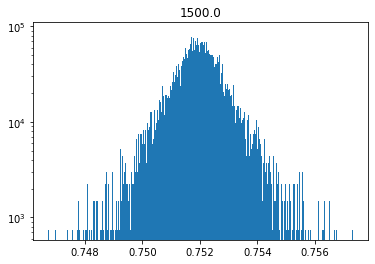

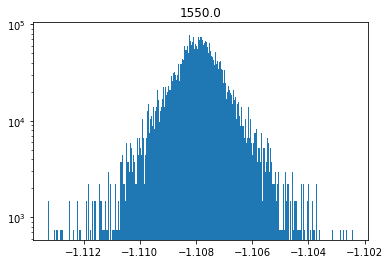

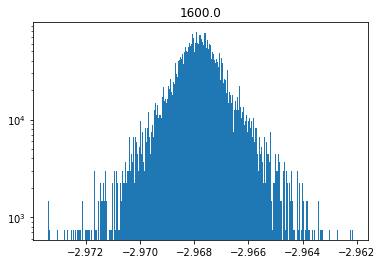

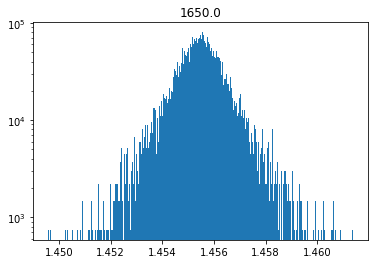

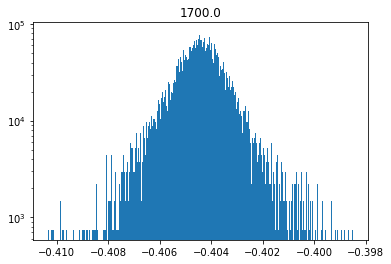

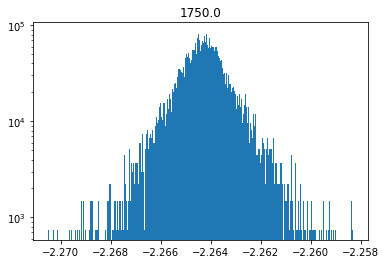

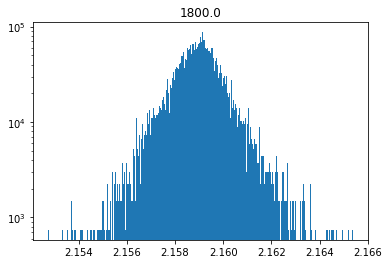

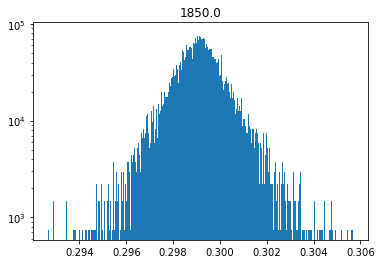

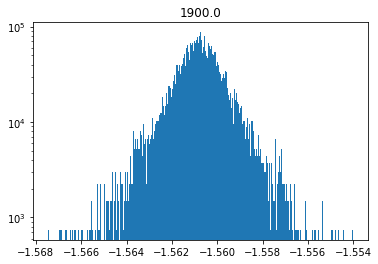

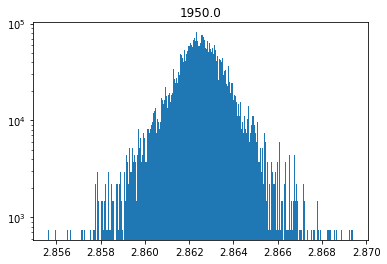

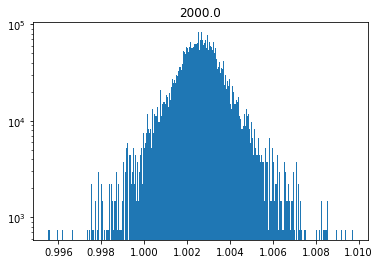

In [12]:
results5ms = analyzeDataset(dataset5ms, plot=True)

In [49]:
numParts5ms

12140544

## Compare and Contrast these results

549.741513 0.01142934480769253 183247171.0


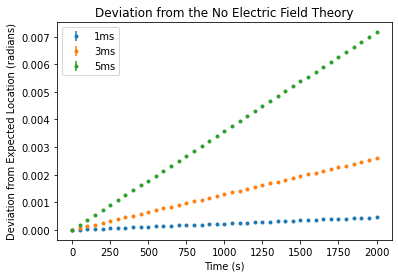

<ipython-input-62-f4a81dadb317>:61: RuntimeWarning: invalid value encountered in true_divide
  plt.errorbar(times, deviations1ms/times/(2.0*np.pi)*1e9, yerr=1e9*results1ms[2]/np.sqrt(numParts1ms)/(2.0*np.pi*times), label='1ms: {:.3f}+-{:.3f}'.format(fitRes1ms[0][0]*1e9, np.sqrt(fitRes1ms[1][0,0])*1e9))
<ipython-input-62-f4a81dadb317>:63: RuntimeWarning: invalid value encountered in true_divide
  plt.errorbar(times, deviations3ms/times/(2.0*np.pi)*1e9, yerr=1e9*results3ms[2]/np.sqrt(numParts3ms)/(2.0*np.pi*times), label='3ms: {:.3f}+-{:.3f}'.format(fitRes3ms[0][0]*1e9, np.sqrt(fitRes3ms[1][0,0])*1e9))
<ipython-input-62-f4a81dadb317>:65: RuntimeWarning: invalid value encountered in true_divide
  plt.errorbar(times, deviations5ms/times/(2.0*np.pi)*1e9, yerr=1e9*results5ms[2]/np.sqrt(numParts5ms)/(2.0*np.pi*times), label='5ms: {:.3f}+-{:.3f}'.format(fitRes5ms[0][0]*1e9, np.sqrt(fitRes5ms[1][0,0])*1e9))


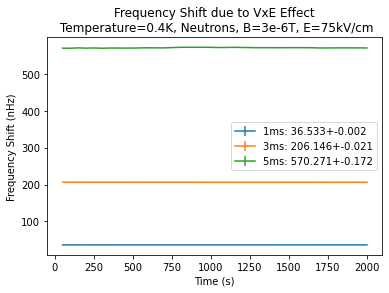

In [62]:
w = parameters0ms[0]['gamma']*np.sqrt(np.sum(np.square(parameters0ms[0]['B0']))) #calculate the frequency
period = 2.0*np.pi/w #calculate the period of the oscillation
print(w, period, parameters3ms[0]['gamma'])
times = results5ms[0]
locationInPeriod = (times/period)%1
trueAngle = abs(locationInPeriod*2.0*np.pi)
'''
deviations0ms = np.copy(results0ms[1])
deviations0ms[deviations0ms<0] += np.pi*2.0
deviations0ms[deviations0ms>2.0*np.pi] -= np.pi*2.0
deviations0ms = np.subtract(deviations0ms, trueAngle)[:]'''

deviations1ms = np.copy(results1ms[1])
deviations1ms[deviations1ms<0] += np.pi*2.0
deviations1ms[deviations1ms>2.0*np.pi] -= np.pi*2.0
deviations1ms = np.subtract(deviations1ms, trueAngle)[:]

'''

deviations2ms = np.copy(results2ms[1])
deviations2ms[deviations2ms<0] += np.pi*2.0
deviations2ms[deviations2ms>2.0*np.pi] -= np.pi*2.0
deviations2ms = np.subtract(deviations2ms, trueAngle)[:]
'''

deviations3ms = np.copy(results3ms[1])
deviations3ms[deviations3ms<0] += np.pi*2.0
deviations3ms[deviations3ms>2.0*np.pi] -= np.pi*2.0
deviations3ms = np.subtract(deviations3ms, trueAngle)[:]
'''
deviations4ms = np.copy(results4ms[1])
deviations4ms[deviations4ms<0] += np.pi*2.0
deviations4ms[deviations4ms>2.0*np.pi] -= np.pi*2.0
deviations4ms = np.subtract(deviations4ms, trueAngle)[:]'''

deviations5ms = np.copy(results5ms[1])
deviations5ms[deviations5ms<0] += np.pi*2.0
deviations5ms[deviations5ms>2.0*np.pi] -= np.pi*2.0
deviations5ms = np.subtract(deviations5ms, trueAngle)[:]

#plt.errorbar(results0ms[0], deviations0ms, yerr=results0ms[2]/np.sqrt(numParts0ms), label='0ms', marker='.', linestyle='none')
plt.errorbar(results1ms[0], deviations1ms, yerr=results1ms[2]/np.sqrt(numParts1ms), label='1ms', marker='.', linestyle='none')
#plt.errorbar(results2ms[0], deviations2ms, yerr=results2ms[2]/np.sqrt(numParts2ms), label='2ms', marker='.', linestyle='none')
plt.errorbar(results3ms[0], deviations3ms, yerr=results3ms[2]/np.sqrt(numParts3ms), label='3ms', marker='.', linestyle='none')
#plt.errorbar(results4ms[0], deviations4ms, yerr=results4ms[2]/np.sqrt(numParts4ms), label='4ms', marker='.', linestyle='none')
plt.errorbar(results5ms[0], deviations5ms, yerr=results5ms[2]/np.sqrt(numParts5ms), label='5ms', marker='.', linestyle='none')
plt.xlabel('Time (s)')
plt.legend()
plt.ylabel('Deviation from Expected Location (radians)')
plt.title('Deviation from the No Electric Field Theory')
plt.show()

#fitRes0ms = np.polyfit(results0ms[0], deviations0ms/(2.0*np.pi), deg=1, cov=True)
fitRes1ms = np.polyfit(results1ms[0], deviations1ms/(2.0*np.pi), deg=1, cov=True)
#fitRes2ms = np.polyfit(results2ms[0], deviations2ms/(2.0*np.pi), deg=1, cov=True)
fitRes3ms = np.polyfit(results3ms[0], deviations3ms/(2.0*np.pi), deg=1, cov=True)
#fitRes4ms = np.polyfit(results4ms[0], deviations4ms/(2.0*np.pi), deg=1, cov=True)
fitRes5ms = np.polyfit(results5ms[0], deviations5ms/(2.0*np.pi), deg=1, cov=True)

#plt.errorbar(times, deviations0ms/times/(2.0*np.pi)*1e9, yerr=1e9*results0ms[2]/np.sqrt(numParts0ms)/(2.0*np.pi*times), label='0ms: {:.3f}+-{:.3f}'.format(fitRes0ms[0][0]*1e9, np.sqrt(fitRes0ms[1][0,0])*1e9))
plt.errorbar(times, deviations1ms/times/(2.0*np.pi)*1e9, yerr=1e9*results1ms[2]/np.sqrt(numParts1ms)/(2.0*np.pi*times), label='1ms: {:.3f}+-{:.3f}'.format(fitRes1ms[0][0]*1e9, np.sqrt(fitRes1ms[1][0,0])*1e9))
#plt.errorbar(times, deviations2ms/times/(2.0*np.pi)*1e9, yerr=1e9*results2ms[2]/np.sqrt(numParts2ms)/(2.0*np.pi*times), label='2ms: {:.3f}+-{:.3f}'.format(fitRes2ms[0][0]*1e9, np.sqrt(fitRes2ms[1][0,0])*1e9))
plt.errorbar(times, deviations3ms/times/(2.0*np.pi)*1e9, yerr=1e9*results3ms[2]/np.sqrt(numParts3ms)/(2.0*np.pi*times), label='3ms: {:.3f}+-{:.3f}'.format(fitRes3ms[0][0]*1e9, np.sqrt(fitRes3ms[1][0,0])*1e9))
#plt.errorbar(times, deviations4ms/times/(2.0*np.pi)*1e9, yerr=1e9*results4ms[2]/np.sqrt(numParts4ms)/(2.0*np.pi*times), label='4ms: {:.3f}+-{:.3f}'.format(fitRes4ms[0][0]*1e9, np.sqrt(fitRes4ms[1][0,0])*1e9))
plt.errorbar(times, deviations5ms/times/(2.0*np.pi)*1e9, yerr=1e9*results5ms[2]/np.sqrt(numParts5ms)/(2.0*np.pi*times), label='5ms: {:.3f}+-{:.3f}'.format(fitRes5ms[0][0]*1e9, np.sqrt(fitRes5ms[1][0,0])*1e9))
plt.xlabel('Time (s)')
plt.ylabel('Frequency Shift (nHz)')
plt.title('Frequency Shift due to VxE Effect\n Temperature=0.4K, Neutrons, B=3e-6T, E=75kV/cm')
plt.legend()
#plt.yscale('log')
plt.show()

In [39]:
#fitRes0ms = np.polyfit(results0ms[0], deviations0ms/(2.0*np.pi), deg=1, cov=True)
fitRes1ms = np.polyfit(results1ms[0], deviations1ms/(2.0*np.pi), deg=1, cov=True)
#fitRes2ms = np.polyfit(results2ms[0], deviations2ms/(2.0*np.pi), deg=1, cov=True)
fitRes3ms = np.polyfit(results3ms[0], deviations3ms/(2.0*np.pi), deg=1, cov=True)
#fitRes4ms = np.polyfit(results4ms[0], deviations4ms/(2.0*np.pi), deg=1, cov=True)
fitRes5ms = np.polyfit(results5ms[0], deviations5ms/(2.0*np.pi), deg=1, cov=True)

In [40]:
#print('Drift 0ms:', fitRes0ms[0], np.sqrt(np.diag(fitRes0ms[1])))
print('Drift 1ms:', fitRes1ms[0], np.sqrt(np.diag(fitRes1ms[1])))
#print('Drift 2ms:', fitRes2ms[0], np.sqrt(np.diag(fitRes2ms[1])))
print('Drift 3ms:', fitRes3ms[0], np.sqrt(np.diag(fitRes3ms[1])))
#print('Drift 4ms:', fitRes4ms[0], np.sqrt(np.diag(fitRes4ms[1])))
print('Drift 5ms:', fitRes5ms[0], np.sqrt(np.diag(fitRes5ms[1])))

Drift 1ms: [ 3.65330874e-08 -2.10843932e-08] [2.46245516e-12 2.86111435e-09]
Drift 3ms: [2.06146307e-07 3.33885907e-08] [2.13606336e-11 2.48188134e-08]
Drift 5ms: [5.70271201e-07 2.28682726e-07] [1.71723336e-10 1.99524486e-07]


In [78]:
datasetFullField.shape

(10780672, 41)